In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
data = {
    "Experience_Years" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    "Training_Hours" : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 8, 12, 18, 25, 35, 40, 50, 60, 65, 70],
    "Attendance" : [70, 75, 80, 82, 85, 88, 90, 92, 94, 95, 74, 78, 83, 86, 89, 91, 93, 95, 97, 98]
}

df = pd.DataFrame(data)

In [39]:
df

,Experience_Years,Training_Hours,Attendance
0,1,5,70
1,2,10,75
2,3,15,80
3,4,20,82
4,5,25,85
5,6,30,88
6,7,35,90
7,8,40,92
8,9,45,94
9,10,50,95


In [40]:
df_copy = df.copy()
df_copy

,Experience_Years,Training_Hours,Attendance
0,1,5,70
1,2,10,75
2,3,15,80
3,4,20,82
4,5,25,85
5,6,30,88
6,7,35,90
7,8,40,92
8,9,45,94
9,10,50,95


In [41]:
df_copy.describe()

,Experience_Years,Training_Hours,Attendance
count,20.000000,20.000000,20.000000
mean,8.250000,32.900000,86.750000
std,5.447114,19.444658,8.162011
min,1.000000,5.000000,70.000000
25%,4.000000,17.250000,81.500000
50%,7.500000,32.500000,88.500000
75%,10.500000,46.250000,93.250000
max,20.000000,70.000000,98.000000


## Derived Experience level

In [42]:
df_copy["Experience_Level"] = pd.cut(
    df_copy["Experience_Years"],
    bins=[0, 2, 5, 10, 20, 40],
    labels=["Beginner", "Junior", "Mid", "Senior", "Expert"]
)

In [43]:
df_copy

,Experience_Years,Training_Hours,Attendance,Experience_Level
0,1,5,70,Beginner
1,2,10,75,Beginner
2,3,15,80,Junior
3,4,20,82,Junior
4,5,25,85,Junior
5,6,30,88,Mid
6,7,35,90,Mid
7,8,40,92,Mid
8,9,45,94,Mid
9,10,50,95,Mid


## Derived Attendance Rate

In [44]:
df_copy["Attendance_Rate"] = df_copy["Attendance"] / 365

In [45]:
df_copy

,Experience_Years,Training_Hours,Attendance,Experience_Level,Attendance_Rate
0,1,5,70,Beginner,0.191781
1,2,10,75,Beginner,0.205479
2,3,15,80,Junior,0.219178
3,4,20,82,Junior,0.224658
4,5,25,85,Junior,0.232877
5,6,30,88,Mid,0.241096
6,7,35,90,Mid,0.246575
7,8,40,92,Mid,0.252055
8,9,45,94,Mid,0.257534
9,10,50,95,Mid,0.260274


## Train a Model - LinearRegression

In [46]:
x = df_copy[["Experience_Years", "Training_Hours", "Attendance"]]
y = df_copy["Attendance_Rate"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

print("Training set size (x_train):", x_train.shape)
print("Testing set size (x_test):", x_test.shape)
print("Training labels size (y_train):", y_train.shape)
print("Testing labels size (y_test):", y_test.shape)

Training set size (x_train): (18, 3)
Testing set size (x_test): (2, 3)
Training labels size (y_train): (18,)
Testing labels size (y_test): (2,)


In [47]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Mean Squared Error: 1.925929944387236e-33
R-squared: 1.0


In [48]:
mae_lr = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (Linear Regression):", mae_lr)

rmse_lr = np.sqrt(mse)
print("Root Mean Squared Error (Linear Regression):", rmse_lr)

Mean Absolute Error (Linear Regression): 4.163336342344337e-17
Root Mean Squared Error (Linear Regression): 4.3885418357208765e-17


## Train Model - Decision Tree Regressor. 

In [49]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=4)
dt_model.fit(x_train, y_train)

y_dt_pred = dt_model.predict(x_test)

dt_mse = mean_squared_error(y_test, y_dt_pred)
print("Decision Tree Mean Squared Error:", dt_mse)

dt_r2 = r2_score(y_test, y_dt_pred)
print("Decision Tree RR\u00B2:", dt_r2)

Decision Tree Mean Squared Error: 6.0987051979733645e-05
Decision Tree RR²: 0.948


In [52]:
mae_dt = mean_absolute_error(y_test, y_dt_pred)
rmse_dt = np.sqrt(dt_mse)

print("Mean Absolute Error (Decision Tree):", f"{mae_dt:.6f}")
print("Root Mean Squared Error (Decision Tree):", f"{rmse_dt:.6f}")

Mean Absolute Error (Decision Tree): 0.006164
Root Mean Squared Error (Decision Tree): 0.007809


### comparison

In [50]:
print("Model Comparison: ")

print(f"Linear Regression - MSE: {mse}, R²: {r2}")
print(f"Decision Tree - MSE: {dt_mse}, R²: {dt_r2}")

Model Comparison: 
Linear Regression - MSE: 1.925929944387236e-33, R²: 1.0
Decision Tree - MSE: 6.0987051979733645e-05, R²: 0.948


## Evaluate model performance

### Visualization: Actual vs Predicted

In [54]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

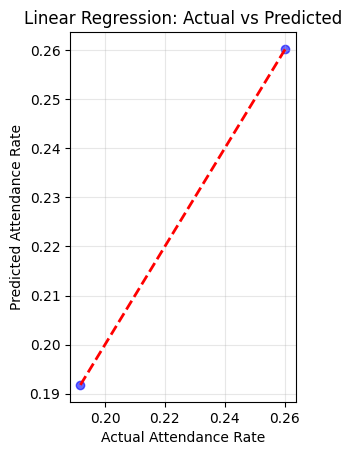

In [ ]:
# Linear Regression plot

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Attendance Rate')
plt.ylabel('Predicted Attendance Rate')
plt.grid(True, alpha=0.3)

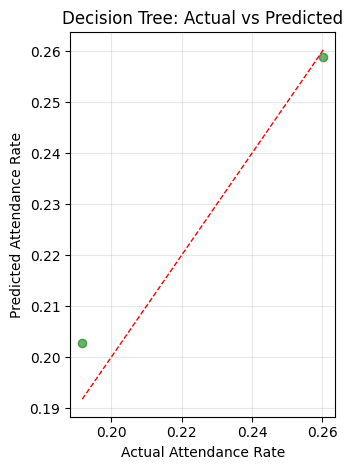

In [59]:
# Decision Tree plot

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_dt_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual Attendance Rate')
plt.ylabel('Predicted Attendance Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()